<a href="https://colab.research.google.com/github/Sontakkepratham/aerial-detection/blob/main/Aerial_Classificatio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow matplotlib scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
train_path = "/content/drive/MyDrive/classification_dataset/train"
val_path = "/content/drive/MyDrive/classification_dataset/valid"
test_path = "/content/drive/MyDrive/classification_dataset/test"

In [6]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'aadhar card.pdf', 'Nidhi❤️🥰🌏', 'Document from prathamsontakke8 (1).pdf', 'IMG20240103223426.jpg', 'Document from prathamsontakke8.pdf', 'Adobe Scan 25-Jan-2024.pdf', 'Video from prathamsontakke8', 'sajna pe dil aagaya ', 'Anniversary ', 'IMG-20241017-WA0006.jpg', 'Job offer ', 'Photo from Pratham Sontakke (1)', 'Photo from Pratham Sontakke', 'Copy of Photo from Pratham Sontakke', '2024-10-30 20-45-14.mp4', 'Meet and forum videos  ', 'USA 2024', 'Script 4 (1).gdoc', 'ONE BY TWO', 'VID_20250322_141509569.mp4', 'VID_20250322_142025294.mp4', 'Chole kulche', 'Document from Pratham.pdf', 'Backlog application .gdoc', 'Automobile Engineering', 'Script 3.gdoc', 'App_3151888990_3151888990_Cons_CIR_Dhruv.gdoc', "Domino's Script Swadesh Bites.gdoc", 'Script 4.gdoc', 'Friendship day ', 'Flop To Phoenix Challenge.gdoc', 'Product lens.gdoc', 'Solving What Matters.gdoc', 'oppa korean truck.gdoc', 'Taylor Swift _ Lover Remix Feat_ Shawn Mendes _Lyric Video_.mp3', 'FocusMate.gdoc', 

In [8]:
classes = os.listdir(train_path)

print("Classes found:", classes)

for cls in classes:
  count = len(os.listdir(os.path.join(train_path, cls)))
  print(f"{cls}: {count}images")

Classes found: ['drone', 'bird']
drone: 1248images
bird: 1414images


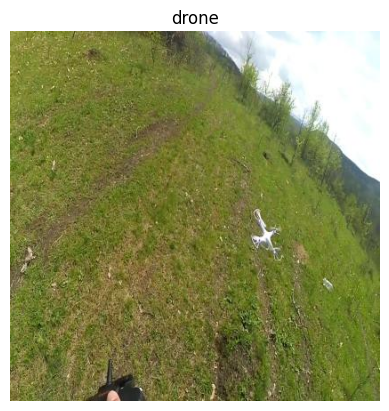

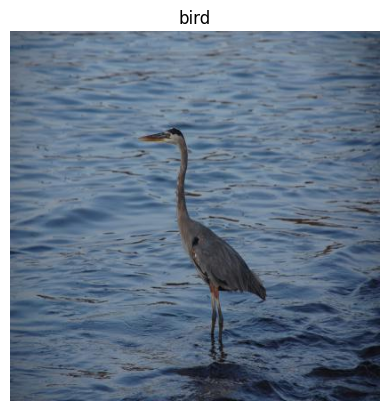

In [9]:
import random
from PIL import Image

for cls in classes:
  folder = os.path.join(train_path, cls)
  img_name = random.choice(os.listdir(folder))
  img_path = os.path.join(folder, img_name)

  img = Image.open(img_path)
  plt.imshow(img)
  plt.title(cls)
  plt.axis("off")
  plt.show()

In [19]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=35,
    zoom_range=0.4,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [11]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'binary'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'binary'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size = IMG_SIZE,
    batch_size = 1,
    class_mode = 'binary',
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [23]:
model = tf.keras.Sequential([
    layers.Input(shape=(224,224,3)),

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')


])

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

class_weight = {
    0: 1.0,
    1: 1.3
}

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.5887 - loss: 0.7395 - val_accuracy: 0.6742 - val_loss: 0.5640
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.7126 - loss: 0.6332 - val_accuracy: 0.7059 - val_loss: 0.5792
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.7397 - loss: 0.5815 - val_accuracy: 0.7602 - val_loss: 0.5620
Epoch 4/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.7532 - loss: 0.5446 - val_accuracy: 0.7624 - val_loss: 0.4669
Epoch 5/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.7923 - loss: 0.4834 - val_accuracy: 0.8167 - val_loss: 0.4180
Epoch 6/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.8140 - loss: 0.4553 - val_accuracy: 0.8235 - val_loss: 0.4049
Epoch 7/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.8287 - loss: 0.4268 - val_accuracy: 0.8371 - val_loss: 0.4019
Epoch 8/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.8377 - loss: 0.4139 - val_accuracy: 0.8213 - v

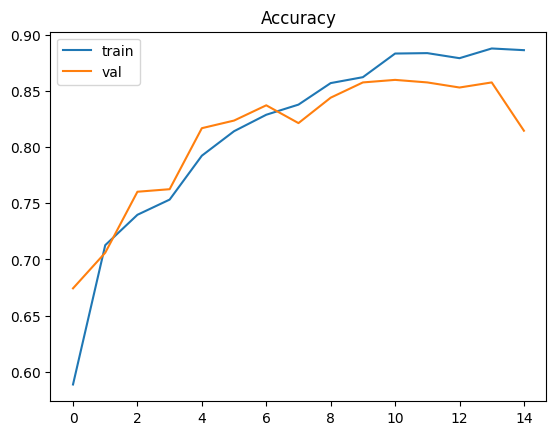

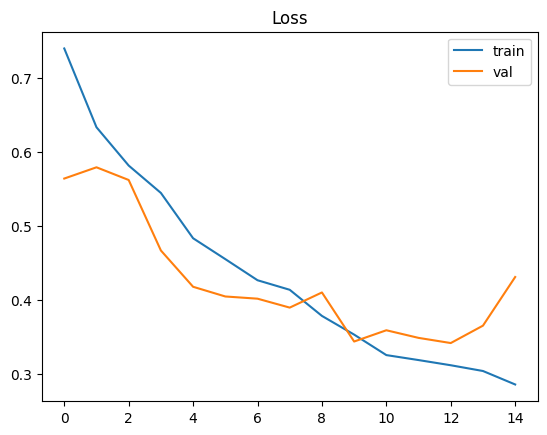

In [27]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [29]:
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.45).astype(int)

y_true = test_data.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step
[[109  12]
 [ 17  77]]
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       121
           1       0.87      0.82      0.84        94

    accuracy                           0.87       215
   macro avg       0.87      0.86      0.86       215
weighted avg       0.87      0.87      0.86       215

